# Python for (Open) Neuroscience  
### Lecture 2.2 — Numpy: Operations with arrays
#### Module 02 - Scientific stack

Sara Assecondi

Department of Psychology and Cognitive Sciences

>**Goal of this lecture:** move from “storing data in arrays” to “thinking with arrays”: reshaping, combining, summarizing, broadcasting, and writing vectorized code.

> [Website](https://numpy.org/)   
> [Documentation](https://numpy.org/doc/)
---

## Lecture outline

- Reshaping and transforming arrays
- Transpose, flatten, and reshape
- Concatenation and stacking
- Element-wise operations
- Reductions and the `axis` argument
- Statistical helper functions
- Broadcasting
- Vectorization and performance


In [64]:

import numpy as np
from matplotlib import pyplot as plt


## Recap: why the `axis` argument matters

Many NumPy functions can act:
- on the whole array,
- or along one specific dimension.

In [65]:

a = np.arange(12).reshape(3, 4)
a


array([[ 0,  1,  2,  3],
       [ 4,  5,  6,  7],
       [ 8,  9, 10, 11]])

In [66]:

print("shape:", a.shape)
print("sum of all elements:", np.sum(a))
print("sum over rows collapsed (axis=0):", np.sum(a, axis=0))
print("sum over columns collapsed (axis=1):", np.sum(a, axis=1))


shape: (3, 4)
sum of all elements: 66
sum over rows collapsed (axis=0): [12 15 18 21]
sum over columns collapsed (axis=1): [ 6 22 38]


## Reshaping arrays


In [67]:

a = np.arange(12)
a


array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11])

In [68]:

a.reshape(3, 4)


array([[ 0,  1,  2,  3],
       [ 4,  5,  6,  7],
       [ 8,  9, 10, 11]])

In [69]:

a.reshape(2, 2, 3)


array([[[ 0,  1,  2],
        [ 3,  4,  5]],

       [[ 6,  7,  8],
        [ 9, 10, 11]]])

### Transpose


In [70]:

m = np.arange(6).reshape(3, 2)
print("m = ", m)
print("m shape =", m.shape)


m =  [[0 1]
 [2 3]
 [4 5]]
m shape = (3, 2)


In [71]:
# transpose with attribute
m.T


array([[0, 2, 4],
       [1, 3, 5]])

In [72]:
# transpose with axis parameter
m = np.arange(12).reshape(3, 2, 2)
print("m = ", m)
print("m shape =", m.shape)

m =  [[[ 0  1]
  [ 2  3]]

 [[ 4  5]
  [ 6  7]]

 [[ 8  9]
  [10 11]]]
m shape = (3, 2, 2)


In [73]:

m_transp = np.transpose(m, axes=(1, 0, 2))
print("m_transp = ", m_transp)
print("m shape =", m_transp.shape)

m_transp =  [[[ 0  1]
  [ 4  5]
  [ 8  9]]

 [[ 2  3]
  [ 6  7]
  [10 11]]]
m shape = (2, 3, 2)


### Flattening


In [74]:

x = np.arange(24).reshape(2, 3, 4)
x.flatten()


array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19, 20, 21, 22, 23])

## Combining arrays


### `np.concatenate()`


In [75]:

arr_list = [np.zeros((2, 3)), np.ones((1, 3))]
np.concatenate(arr_list, axis=0)


array([[0., 0., 0.],
       [0., 0., 0.],
       [1., 1., 1.]])

In [76]:

arr_list = [np.zeros((3, 2)), np.ones((3, 2))]
np.concatenate(arr_list, axis=1)


array([[0., 0., 1., 1.],
       [0., 0., 1., 1.],
       [0., 0., 1., 1.]])

### `np.stack()`

`stack()` joins a sequence of arrays along a **new axis**.


In [77]:
a = np.zeros((3, 2))
b = np.ones((3, 2))
print("shape a :", a.shape)
print("shape b :", b.shape)

shape a : (3, 2)
shape b : (3, 2)


In [78]:

arr_list = [a, b]
c = np.stack(arr_list, axis=0)
print("shape c :", c.shape)

shape c : (2, 3, 2)


In [79]:

np.stack(arr_list, axis=1).shape


(3, 2, 2)

## Element-wise operations


In [80]:
a = np.ones(3)
print("a = ", a)

b = np.ones(3) + 1
print("b = ", b)

a =  [1. 1. 1.]
b =  [2. 2. 2.]


In [81]:

np.array([1, 2, 3]) ** 2


array([1, 4, 9])

In [82]:

a = np.array([[1, 2],
              [3, 4]])

b = np.array([[10, 20],
              [30, 40]])

a + b


array([[11, 22],
       [33, 44]])

If shapes are incompatible, NumPy raises an error.


In [83]:

np.ones((2, 3)) * np.ones((4, 5))


ValueError: operands could not be broadcast together with shapes (2,3) (4,5) 

## Reductions and descriptive statistics


### `np.sum()` and `np.mean()`

- `sum()` returns the sum of the array elements over the given axis.
- `mean()` computes the arithmetic mean along the specified axis.

In [84]:

arr = np.arange(12).reshape(3, 4)
print(np.sum(arr))
print(np.sum(arr, axis=0))
print(np.sum(arr, axis=1))


66
[12 15 18 21]
[ 6 22 38]


In [85]:

arr = np.arange(12).reshape(3, 4)
print(np.mean(arr))
print(np.mean(arr, axis=0))
print(np.mean(arr, axis=1))


5.5
[4. 5. 6. 7.]
[1.5 5.5 9.5]


### `np.nansum` and `np.nanmean()`


In [87]:

arr = np.array([[1.0, 2.0, np.nan],
                [4.0, np.nan, 6.0]])

print(np.nanmean(arr))
print(np.nanmean(arr, axis=0))

print(np.mean(arr))

3.25
[2.5 2.  6. ]
nan


### `std()`, `median()`, `min()`, `max()`

and `np.nanstd()`, `np.nanmedian()`


In [88]:
arr = np.random.normal(0, 3, (1000, 3))
print("arr shape = ",arr.shape)   # (1000, 10)
print("arr dim = ", arr.ndim)    # 2

arr shape =  (1000, 3)
arr dim =  2


In [89]:
print("std : ",np.std(arr))
print("median : ", np.median(arr))
print("min : ", np.min(arr),"max : ", np.max(arr))

std :  2.978867344658901
median :  -0.0724174576358674
min :  -11.193615033098293 max :  10.181103448771532


In [91]:
# along one axis
print("std : ", np.std(arr,axis = 0))
print("median : ", np.median(arr,axis = 0))
print("min : ", np.min(arr,axis = 0), "max : ",np.max(arr,axis = 0))

std :  [2.96977901 2.95609119 3.00657065]
median :  [-0.04548329 -0.29258596  0.08150671]
min :  [-10.53472284 -11.19361503  -9.25529416] max :  [10.17961711  9.77960105 10.18110345]


### `np.percentile()`


In [92]:

arr = np.random.randint(0, 1000, 10000)
print(np.percentile(arr, 25))
print(np.percentile(arr, 50))
print(np.percentile(arr, 75))


253.75
494.5
742.0


### `np.unique()`


In [93]:

a = np.array([1, 2, 2, 2, 3, 3, 4])
print("a = ", a)

values, counts = np.unique(np.array([1, 2, 2, 2, 3, 3, 4]), return_counts=True)
print("values = ", values)
print("counts = ", counts)


a =  [1 2 2 2 3 3 4]
values =  [1 2 3 4]
counts =  [1 3 2 1]


### `np.diff()` and `np.cumsum()`

- `np.diff()` calculates the n-th discrete difference along the given axis. The first difference is given by `out[i] = a[i+1] - a[i] `
- `np.cumsum()` returns the cumulative sum of the elements along a given axis.


In [94]:

arr = np.array([1, 2, 3, 5, 8])
print(np.diff(arr))
print(np.cumsum(arr))


[1 1 2 3]
[ 1  3  6 11 19]


## Broadcasting
[doc page](https://numpy.org/doc/stable/user/basics.broadcasting.html#broadcasting)

**Broadcasting** describes how NumPy treats arrays with different shapes during arithmetic operations. Subject to certain constraints, the smaller array is “broadcast” across the larger array so that they have compatible shapes. 

- Broadcasting provides a means of vectorizing array operations so that looping occurs in C instead of Python. 
- It does this without making needless copies of data and usually leads to efficient algorithm implementations. There are, however, cases where broadcasting is a bad idea because it leads to inefficient use of memory that slows computation.



**Broadcasting one-to-one**   
Operations are usually done on pairs of arrays on an element-by-element basis


In [95]:

a = np.array([1.0, 2.0, 3.0])
b = np.array([2.0, 2.0, 2.0])
a * b

array([2., 4., 6.])

**Broadcasting many-to-one**    
When an array and a scalar value are combined in an operation

In [97]:

a = np.array([1.0, 2.0, 3.0])
b = 2.0
a * b

array([2., 4., 6.])

The result is equivalent to the previous example where `b` was an array. 

We can think of the scalar `b` being stretched during the arithmetic operation into an array with the same shape as `a`. The new elements in `b`, as shown below, are simply copies of the original scalar. 

The stretching analogy is only conceptual. NumPy is smart enough to use the original scalar value without actually making copies so that broadcasting operations are as memory and computationally efficient as possible.

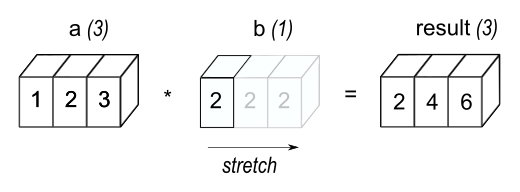

In [98]:

from IPython.display import Image, display
display(Image("fig_broadcasting.png"))

### General broadcasting rules

- When operating on two arrays, NumPy compares their shapes element-wise. 
- Compare shapes from the **rightmost dimension** to the left.

Two dimensions are compatible when:
- they are equal, or
- one of them is 1.


In [99]:
a = np.ones((5, 4))
b = np.arange(4)
print(a.shape, b.shape)
print((a + b).shape)

(5, 4) (4,)
(5, 4)


In [100]:
print("a = ",a)
print("b = ",b)
print("a+b = ",a+b)

a =  [[1. 1. 1. 1.]
 [1. 1. 1. 1.]
 [1. 1. 1. 1.]
 [1. 1. 1. 1.]
 [1. 1. 1. 1.]]
b =  [0 1 2 3]
a+b =  [[1. 2. 3. 4.]
 [1. 2. 3. 4.]
 [1. 2. 3. 4.]
 [1. 2. 3. 4.]
 [1. 2. 3. 4.]]


### When broadcasting fails


In [101]:
a = np.ones((5, 4))
b = np.ones(5)

print("a shape:", a.shape)
print("b shape:", b.shape)

print("a = ", a)
print("b = ", b)

a shape: (5, 4)
b shape: (5,)
a =  [[1. 1. 1. 1.]
 [1. 1. 1. 1.]
 [1. 1. 1. 1.]
 [1. 1. 1. 1.]
 [1. 1. 1. 1.]]
b =  [1. 1. 1. 1. 1.]


In [102]:
a + b

ValueError: operands could not be broadcast together with shapes (5,4) (5,) 

**Shape mismatch** sometimes can be fixed  with a **singleton dimension**


In [103]:

b = np.ones(5)
b2 = b[:, np.newaxis]

print("b2 shape:", b2.shape)
print((np.ones((5, 4)) + b2).shape)


b2 shape: (5, 1)
(5, 4)


Another way to **avoid mismatched dimensions**: when reducing along an axis, NumPy normally removes that axis.
With `keepdims=True`, the reduced axis is kept with size 1.

In [104]:
X = np.array([[1, 2, 3],
              [4, 5, 6]])

print("mean of X = ", X.mean(axis=1))
print("shape of X = ", X.mean(axis=1).shape)  

mean of X =  [2. 5.]
shape of X =  (2,)


with `keepdims`

In [105]:
print("mean of X = ", X.mean(axis=1, keepdims=True)) 
print("mean of X = ", X.mean(axis=1, keepdims=True).shape) 

mean of X =  [[2.]
 [5.]]
mean of X =  (2, 1)


## Write code the NumPy way: vectorization

In NumPy, you usually want to replace Python loops with operations over full arrays.


In [106]:
vector_1 = np.random.normal(0, 1, (1_000_000,))
vector_2 = np.random.normal(0, 1, (1_000_000,))

In [107]:
%%timeit
product = np.zeros(vector_1.shape)  # initialize empty result vector

# Compute the multiplication in a loop:
for i in range(vector_1.shape[0]):
    product[i] = vector_1[i] * vector_2[i]

277 ms ± 8.32 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [108]:
%%timeit
product = vector_1 * vector_2

1.4 ms ± 62 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)
